In [1]:
from tqdm import tqdm
from multiprocess import Pool
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from precip_ext_model import *

In [2]:
params={     
    'axes.labelsize'  : '14',   
    'axes.titlesize'  : '14',  
    'xtick.labelsize' :'14',
    'ytick.labelsize' :'14',    
    'lines.linewidth' : '2' ,   
    'legend.fontsize' : '12', 
    'figure.figsize'   : '12, 7'    
}
plt.rcParams.update(params)


In [3]:

def scatter_to_contour(x_in,y_in,z_in):
    # 1D scattered data
    x = np.asarray(x_in)
    y = np.asarray(y_in)
    z = np.asarray(z_in)

    # make regular grid
    xi = np.linspace(x.min(), x.max(), 100)
    yi = np.linspace(y.min(), y.max(), 100)
    Xi, Yi = np.meshgrid(xi, yi)

    # interpolate scattered data onto grid
    Zi = griddata((x, y), z, (Xi, Yi), method="linear")
    return Xi, Yi, Zi

In [4]:
z_lcl = 1200

# 1. Create all (RH, P) pairs
rng = np.random.default_rng(42) ## make things reproducible
# RH_values = np.sort(rng.uniform(0.01, 0.99, 100))
# P_values = np.sort(rng.uniform(0, 10, 20))

## or using sequences
RH_values = np.linspace(0.01, 0.99, 50)
P_values = np.linspace(0, 20, 30)

param_pairs = [(RH, P) for RH in RH_values for P in P_values]

# 2. Define worker function
def worker(args):
    RH, P = args
    CAPE_u, CAPE_ext, dh, sat_def,dz = spectral_plume_lcl(
        model_type="precip", RH=RH, P=P, z_lcl=z_lcl,
        get_plane=True, plotting=False, save_data=False
    )
    return CAPE_u, CAPE_ext, dh, sat_def, P, RH,dz

# 3. Run in parallel
num_cpus = 8
with Pool(processes=num_cpus) as pool:
    results = list(tqdm(pool.imap(worker, param_pairs), total=len(param_pairs)))

# 4. Unpack results
CAPEu_list, CAPEext_list, dh_list, sat_def_list, P_list,RH_list,dz_list = zip(*results)
CAPEu_list = list(CAPEu_list)
CAPEext_list = list(CAPEext_list)
dh_list = list(dh_list)
sat_def_list = list(sat_def_list)
P_list = list(P_list)
RH_list = list(RH_list)
dz_list = list(dz_list)

# 5. Save to CSV
df = pd.DataFrame({
    "CAPE_u":CAPEu_list,
    "CAPE_ext": CAPEext_list,
    "dh": dh_list,
    "sat_def": sat_def_list,
    "P": P_list,
    "RH": RH_list,
    "dz": dz_list
            })
df.to_csv(f"LCL_ext_{z_lcl}m.csv", index=False)

100%|██████████| 1500/1500 [01:52<00:00, 13.35it/s]


In [5]:
## prepare arrays for plotting
sat_def_arr = np.array(sat_def_list)*const.Lv0/1000
dh_arr = np.array(dh_list)/1000
w_arr = np.sqrt(2*np.array(CAPEext_list))
dz_arr = np.array(dz_list)/1000


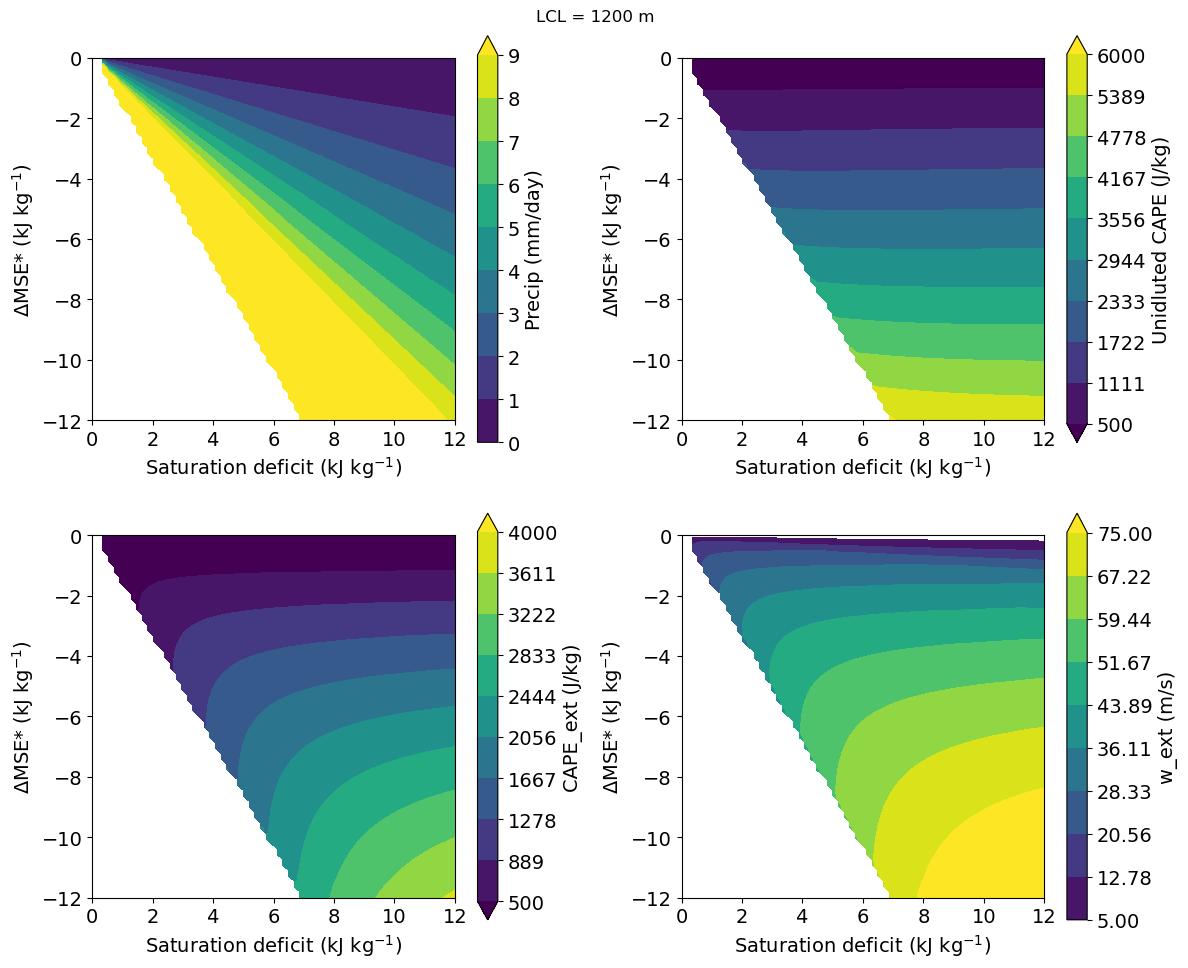

In [6]:
fig = plt.figure(figsize=(12,10))

ax1 = fig.add_subplot(221)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, P_list)
cf1 = ax1.contourf(Xi, Yi, Zi, levels=np.linspace(0, 9, 10),extend="max")
fig.colorbar(cf1, ax=ax1, label="Precip (mm/day)")
ax1.set_xlim(0,12)
ax1.set_ylim(-12,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax1.set_aspect('equal')

ax2 = fig.add_subplot(222)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, CAPEu_list)
cf2 = ax2.contourf(Xi, Yi, Zi,levels=np.linspace(500,6000,10),extend="both")
fig.colorbar(cf2, ax=ax2,label="Unidluted CAPE (J/kg)")
ax2.set_xlim(0,12)
ax2.set_ylim(-12,0)
ax2.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax2.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax2.set_aspect('equal')

ax3 = fig.add_subplot(223)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, CAPEext_list)
cf3 = ax3.contourf(Xi, Yi, Zi,levels=np.linspace(500,4000,10),extend="both")
fig.colorbar(cf3, ax=ax3,label="CAPE_ext (J/kg)")
ax3.set_xlim(0,12)
ax3.set_ylim(-12,0)
ax3.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax3.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax3.set_aspect('equal')

ax4 = fig.add_subplot(224)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf4 = ax4.contourf(Xi, Yi, Zi,levels=np.linspace(5,75,10),extend="max")
fig.colorbar(cf4, ax=ax4,label="w_ext (m/s)")
ax4.set_xlim(0,12)
ax4.set_ylim(-12,0)
ax4.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax4.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax4.set_aspect('equal')


plt.suptitle(f"LCL = {z_lcl} m")
plt.tight_layout()

In [4]:
import cmcrameri.cm as cmc


<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:38: SyntaxWarning: invalid escape sequence '\e'
/var/folders/mk/8cspl43d4k981r_vzfv1w594k91l6t/T/ipykernel_89122/3359108339.py:38: SyntaxWarning: invalid escape sequence '\e'
  f"$\epsilon$={-es} km"+r"$^{-1}$",


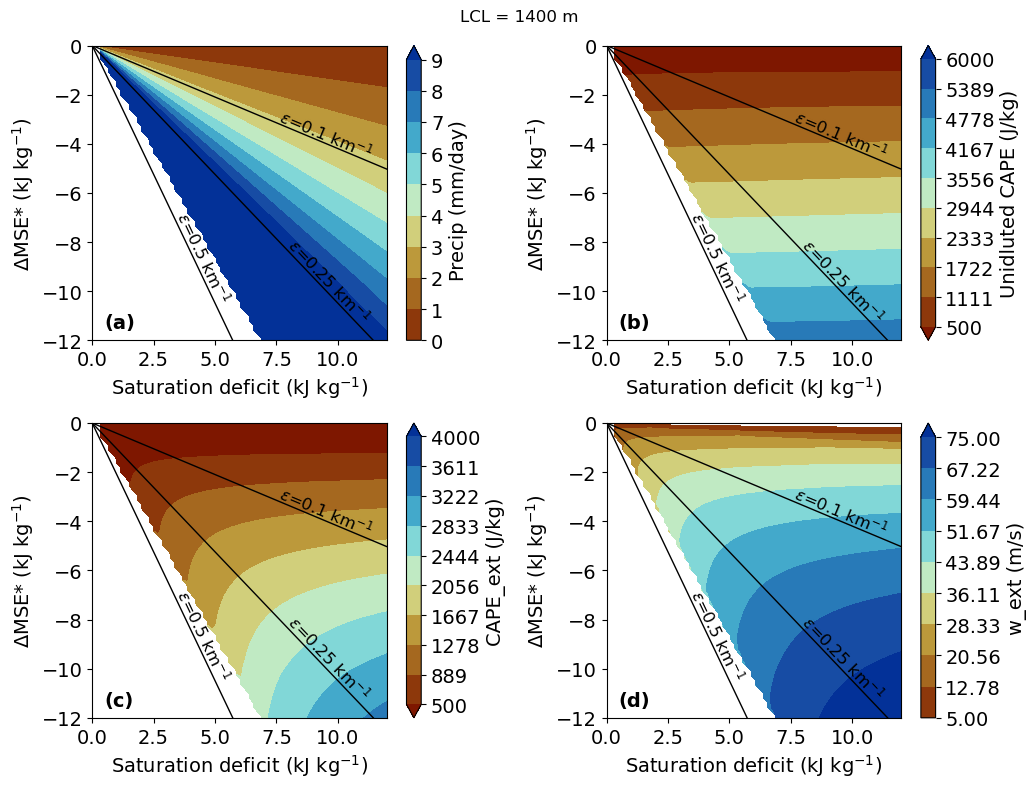

In [5]:
## or read from csv
df = pd.read_csv("LCL_ext_1400m.csv")

sat_def_arr = np.array(df["sat_def"])*const.Lv0/1000
dh_arr = np.array(df["dh"])/1000
P_list = np.array(df["P"])
CAPEu_list = np.array(df["CAPE_u"])
CAPEext_list = np.array(df["CAPE_ext"])
w_arr = np.sqrt(2*CAPEext_list)
dz_arr = np.array(df["dz"])/1000
dz = np.nanmean(dz_arr)
fig = plt.figure(figsize=(10.5,8))

ax1 = fig.add_subplot(221)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, P_list)
cf1 = ax1.contourf(Xi, Yi, Zi, levels=np.linspace(0, 9, 10),extend="max",cmap=cmc.roma)
fig.colorbar(cf1, ax=ax1, label="Precip (mm/day)")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        f"$\epsilon$={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,12)
ax1.set_ylim(-12,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(a)",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')

ax2 = fig.add_subplot(222)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, CAPEu_list)
cf2 = ax2.contourf(Xi, Yi, Zi,levels=np.linspace(500,6000,10),extend="both",cmap=cmc.roma)
fig.colorbar(cf2, ax=ax2,label="Unidluted CAPE (J/kg)")
for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\epsilon$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )
ax2.set_xlim(0,12)
ax2.set_ylim(-12,0)
ax2.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax2.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax2.text(0.5,-11.5,"(b)",fontweight="bold",fontsize=14)

ax2.set_aspect('equal')

ax3 = fig.add_subplot(223)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, CAPEext_list)
cf3 = ax3.contourf(Xi, Yi, Zi,levels=np.linspace(500,4000,10),extend="both",cmap=cmc.roma)
fig.colorbar(cf3, ax=ax3,label="CAPE_ext (J/kg)")
for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\epsilon$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )
ax3.set_xlim(0,12)
ax3.set_ylim(-12,0)
ax3.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax3.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax3.text(0.5,-11.5,"(c)",fontweight="bold",fontsize=14)

ax3.set_aspect('equal')

ax4 = fig.add_subplot(224)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf4 = ax4.contourf(Xi, Yi, Zi,levels=np.linspace(5,75,10),extend="max",cmap=cmc.roma)
fig.colorbar(cf4, ax=ax4,label="w_ext (m/s)")
for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\epsilon$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )
ax4.set_xlim(0,12)
ax4.set_ylim(-12,0)
ax4.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax4.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax4.text(0.5,-11.5,"(d)",fontweight="bold",fontsize=14)

ax4.set_aspect('equal')


plt.suptitle(f"LCL = 1400 m")
plt.tight_layout()

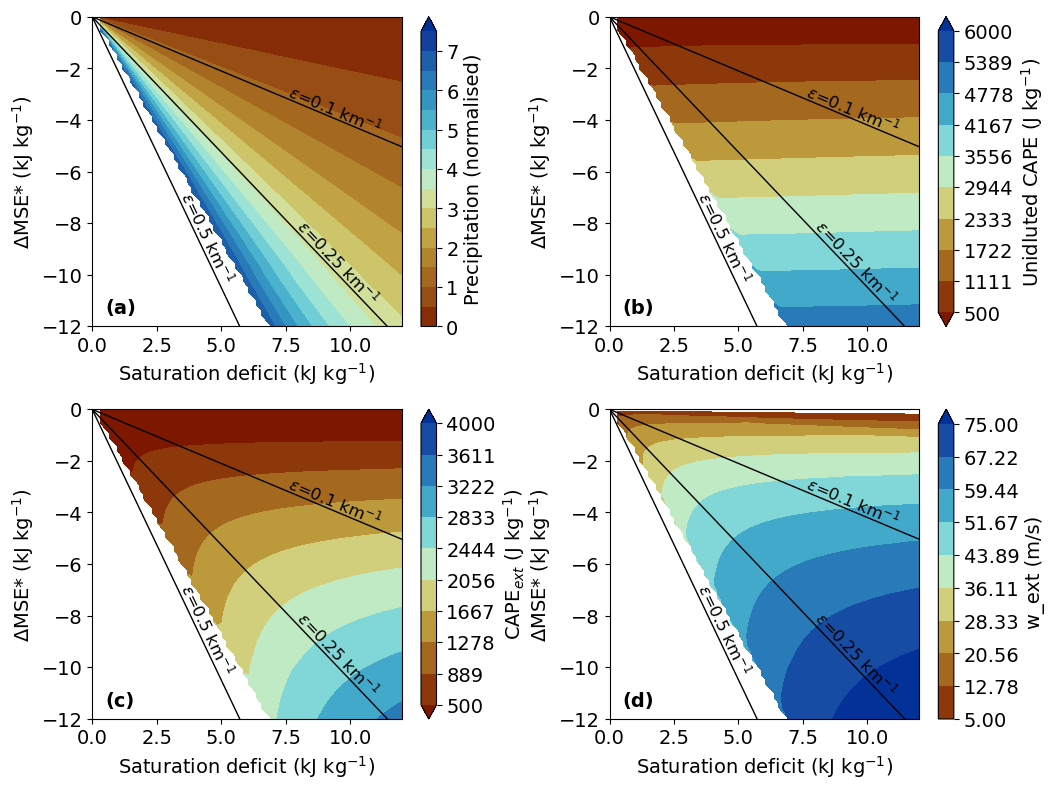

In [6]:
## or read from csv
df = pd.read_csv("LCL_ext_1400m.csv")

sat_def_arr = np.array(df["sat_def"])*const.Lv0/1000
dh_arr = np.array(df["dh"])/1000
P_list = np.array(df["P"])
CAPEu_list = np.array(df["CAPE_u"])
CAPEext_list = np.array(df["CAPE_ext"])
w_arr = np.sqrt(2*CAPEext_list)
dz_arr = np.array(df["dz"])/1000
dz = np.nanmean(dz_arr)

fig = plt.figure(figsize=(10.5,8))

ax1 = fig.add_subplot(221)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, np.array(P_list)/3)
cf1 = ax1.contourf(Xi, Yi, Zi, levels=np.arange(0,8,0.5),extend="max",cmap=cmc.roma)
fig.colorbar(cf1, ax=ax1, label="Precipitation (normalised)")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\epsilon$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,12)
ax1.set_ylim(-12,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(a)",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')

ax2 = fig.add_subplot(222)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, CAPEu_list)
cf2 = ax2.contourf(Xi, Yi, Zi,levels=np.linspace(500,6000,10),extend="both",cmap=cmc.roma)
fig.colorbar(cf2, ax=ax2,label=r"Unidluted CAPE (J kg$^{-1}$)")
for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\epsilon$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )
ax2.set_xlim(0,12)
ax2.set_ylim(-12,0)
ax2.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax2.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax2.text(0.5,-11.5,"(b)",fontweight="bold",fontsize=14)

ax2.set_aspect('equal')

ax3 = fig.add_subplot(223)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, CAPEext_list)
cf3 = ax3.contourf(Xi, Yi, Zi,levels=np.linspace(500,4000,10),extend="both",cmap=cmc.roma)
fig.colorbar(cf3, ax=ax3,label=r"CAPE$_{ext}$ (J kg$^{-1}$)")
for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\epsilon$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )
ax3.set_xlim(0,12)
ax3.set_ylim(-12,0)
ax3.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax3.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax3.text(0.5,-11.5,"(c)",fontweight="bold",fontsize=14)

ax3.set_aspect('equal')

ax4 = fig.add_subplot(224)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf4 = ax4.contourf(Xi, Yi, Zi,levels=np.linspace(5,75,10),extend="max",cmap=cmc.roma)
fig.colorbar(cf4, ax=ax4,label="w_ext (m/s)")
for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\epsilon$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )
ax4.set_xlim(0,12)
ax4.set_ylim(-12,0)
ax4.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax4.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax4.text(0.5,-11.5,"(d)",fontweight="bold",fontsize=14)

ax4.set_aspect('equal')


# plt.suptitle(f"LCL = {z_lcl} m")
plt.tight_layout()

In [12]:
dz

4.195216666666667